# 🎓 Aula 11 — Estudo de Caso Avançado: Modelagem Sequencial de Clima e Energia com LSTMs e GRUs no PyTorch

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/allanspadini/curso-pytorch-infnet/blob/main/aula_11_lstms_grus_features_ciclicas/aula_11_lstms_grus_features_ciclicas_estudo_de_caso_clima_energia_lstm_gru.ipynb)

**Curso:** Redes Neurais Profundas e Visão Computacional — Instituto Infnet  
**Autor:** Prof. Allan Spadini  
**Dataset Oficial:** [Hourly Energy Consumption, Generation & Weather (Kaggle / nicholasjhana)](https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather)

---

### 🎯 Objetivos Desta Prática Avançada:
Neste estudo de caso prático de engenharia de Machine Learning, abordamos os **cinco desafios críticos da modelagem sequencial multivariada** em séries temporais horárias reais (clima e demanda energética):

1. **Engenharia de Variáveis Cíclicas:** Por que representar hora (0–23) e mês (1–12) como inteiros lineares prejudica redes neurais e como aplicar a **transformação trigonométrica $(\sin, \cos)$** no círculo unitário.
2. **Estabilidade de Gradientes & Gradient Clipping:** Diagnosticar gradientes explosivos em sequências longas e aplicar `torch.nn.utils.clip_grad_norm_`.
3. **Agendamento de Taxa de Aprendizado (LR Scheduling) & Early Stopping:** Superar platôs na perda de validação com `ReduceLROnPlateau` e restaurar os melhores pesos do modelo.
4. **Dimensionamento de Arquitetura (Capacidade vs Overfitting):** Avaliar o impacto da profundidade (`num_layers`), dimensão oculta (`hidden_size`) e regularização com Dropout.
5. **Substituição de LSTM por GRU:** Comparar a anatomia dos portões, demonstrar a economia de 25% de parâmetros e avaliar métricas de teste (**MAE**, **RMSE** e **WAPE**).


## 1. Configuração do Ambiente e Reprodutibilidade

Instalamos o `kagglehub` para download automático do dataset e importamos os módulos essenciais do **PyTorch**, **Scikit-Learn**, **Pandas**, **NumPy** e **Matplotlib**.


In [1]:
# Instalação do kagglehub para download automático no Google Colab
try:
    import kagglehub
except ImportError:
    !pip install -q kagglehub
    import kagglehub

import os
import glob
import math
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Configurações visuais elegantes
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 5)

# Fixação de sementes para garantir reprodutibilidade
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Dispositivo de Execução: {device}")


🚀 Dispositivo de Execução: cpu


## 2. Carregamento e Preparação do Dataset

O dataset contém **medições horárias contínuas de 4 anos (2015 a 2018)** de condições climáticas (temperatura, umidade, pressão, vento) e demanda de carga elétrica na Espanha.

Baixamos o dataset via `kagglehub` e carregamos os arquivos `weather_features.csv` e `energy_dataset.csv`.


In [2]:
# Download do dataset via kagglehub
dataset_dir = kagglehub.dataset_download("nicholasjhana/energy-consumption-generation-prices-and-weather")
print(f"📁 Dataset disponível em: {dataset_dir}")

weather_path = os.path.join(dataset_dir, "weather_features.csv")
energy_path = os.path.join(dataset_dir, "energy_dataset.csv")

# Leitura dos dados meteorológicos
df_weather = pd.read_csv(weather_path)
print("Amostra do arquivo meteorológico:")
df_weather.head(3)


📁 Dataset disponível em: /home/allan/.cache/kagglehub/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather/versions/1


Amostra do arquivo meteorológico:


,dt_iso,city_name,temp,temp_min,temp_max,pressure,humidity,wind_speed,wind_deg,rain_1h,rain_3h,snow_3h,clouds_all,weather_id,weather_main,weather_description,weather_icon
0,2015-01-01 00:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
1,2015-01-01 01:00:00+01:00,Valencia,270.475,270.475,270.475,1001,77,1,62,0.0,0.0,0.0,0,800,clear,sky is clear,01n
2,2015-01-01 02:00:00+01:00,Valencia,269.686,269.686,269.686,1002,78,0,23,0.0,0.0,0.0,0,800,clear,sky is clear,01n


### Filtragem por Cidade e Conversão de Temperatura para Celsius

Filtramos as medições da capital (**Madrid**), convertemos o timestamp `dt_iso` para formato datetime padronizado UTC e convertemos a temperatura de Kelvin ($K$) para Celsius (°C):
$$T_{(^\circ\text{C})} = T_{(K)} - 273.15$$


In [3]:
# Filtragem dos dados de Madrid
df_madrid = df_weather[df_weather['city_name'] == 'Madrid'].copy()

# Conversão temporal e remoção de duplicatas de timestamp
df_madrid['dt_iso'] = pd.to_datetime(df_madrid['dt_iso'], utc=True)
df_madrid = df_madrid.drop_duplicates(subset=['dt_iso']).sort_values('dt_iso').reset_index(drop=True)

# Conversão de Kelvin para Celsius
df_madrid['temp_celsius'] = df_madrid['temp'] - 273.15

# Estatísticas descritivas da temperatura
print(f"Total de registros horários: {len(df_madrid):,}")
print(f"Temperatura Mínima: {df_madrid['temp_celsius'].min():.1f}°C | Máxima: {df_madrid['temp_celsius'].max():.1f}°C | Média: {df_madrid['temp_celsius'].mean():.1f}°C")


Total de registros horários: 35,064
Temperatura Mínima: -9.0°C | Máxima: 40.2°C | Média: 15.1°C


### Integração com a Demanda Energética (Total Load)

Carregamos o arquivo `energy_dataset.csv` e integramos a demanda de energia real (`total load actual`) alinhada exatamente ao mesmo timestamp horário:


In [4]:
# Leitura e alinhamento do dataset de energia
df_energy = pd.read_csv(energy_path)
df_energy['time'] = pd.to_datetime(df_energy['time'], utc=True)
df_energy = df_energy.drop_duplicates(subset=['time']).sort_values('time').reset_index(drop=True)

# Merge temporal
df_merged = pd.merge(
    df_madrid,
    df_energy[['time', 'total load actual']],
    left_on='dt_iso',
    right_on='time',
    how='inner'
)

print(f"DataFrame integrado com sucesso: {df_merged.shape[0]:,} linhas horárias.")


DataFrame integrado com sucesso: 35,064 linhas horárias.


### Visualização Gráfica da Série Temporal de Temperatura

Vamos plotar a série temporal completa de 4 anos em Madrid, observando:
1. **Ciclos Sazonais Anuais Fortes:** Verões com temperaturas próximas a 40°C e invernos com mínimas abaixo de 0°C.
2. **Oscilações Diurnas/Noturnas:** Variações diárias de 10°C a 15°C entre dia e noite.


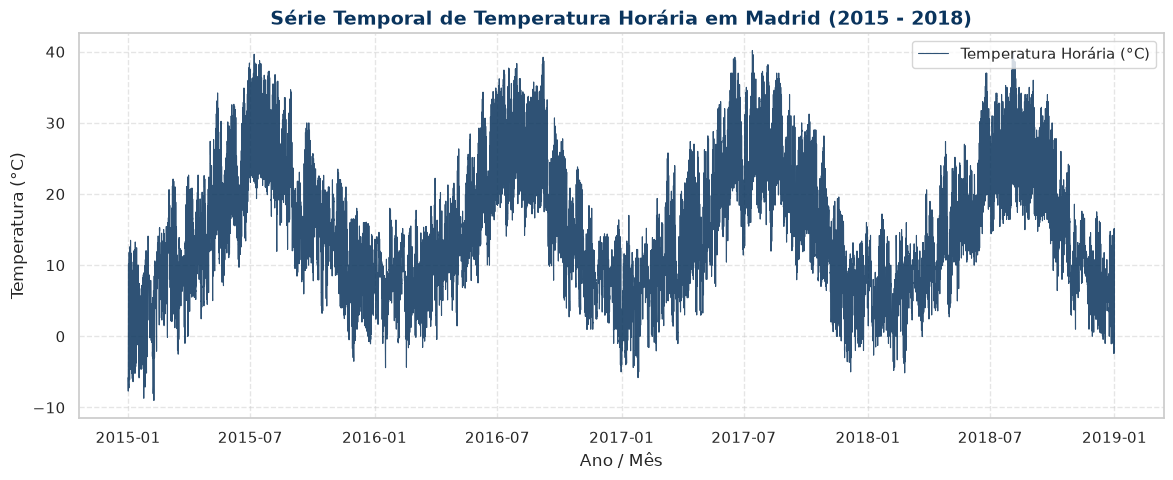

In [5]:
plt.figure(figsize=(14, 5))
plt.plot(df_merged['dt_iso'], df_merged['temp_celsius'], color='#0A345D', linewidth=0.8, alpha=0.85, label='Temperatura Horária (°C)')
plt.title('Série Temporal de Temperatura Horária em Madrid (2015 - 2018)', fontsize=14, fontweight='bold', color='#0A345D')
plt.xlabel('Ano / Mês')
plt.ylabel('Temperatura (°C)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.show()


## 3. Engenharia de Features: O Problema das Variáveis Temporais Cíclicas

### ⚠️ O Erro Comum: Tratar Hora e Mês como Inteiros Lineares
Quando usamos variáveis como `hora_do_dia (0 a 23)` ou `mes (1 a 12)` como inteiros lineares comuns:
- Para a rede neural, a distância numérica entre as **23h e as 00h** é $|23 - 0| = 23$ unidades!
- No entanto, no mundo físico real, 23:00 e 00:00 estão separadas por **apenas 1 hora de distância**.
- O mesmo acontece entre **Dezembro (mês 12) e Janeiro (mês 1)**: a rede enxerga um salto gigantesco de 11 unidades, criando uma **descontinuidade artificial destrutiva** no espaço latente.

---

### ✅ A Solução Matemática: Projeção no Círculo Unitário $(\sin, \cos)$
Projetamos o tempo em duas coordenadas ortogonais no círculo trigonométrico unitário:

$$\text{hour\_sin} = \sin\left(\frac{2\pi \cdot \text{hora}}{24}\right), \quad \text{hour\_cos} = \cos\left(\frac{2\pi \cdot \text{hora}}{24}\right)$$

$$\text{month\_sin} = \sin\left(\frac{2\pi \cdot \text{mês}}{12}\right), \quad \text{month\_cos} = \cos\left(\frac{2\pi \cdot \text{mês}}{12}\right)$$

Dessa forma, $23\text{h}$ e $00\text{h}$ ficam perfeitamente vizinhas e contínuas no espaço bidimensional!


In [6]:
# Extração de componentes temporais
df_merged['hour'] = df_merged['dt_iso'].dt.hour
df_merged['month'] = df_merged['dt_iso'].dt.month

# Transformação trigonométrica cíclica no círculo unitário
df_merged['hour_sin'] = np.sin(2 * np.pi * df_merged['hour'] / 24.0)
df_merged['hour_cos'] = np.cos(2 * np.pi * df_merged['hour'] / 24.0)

df_merged['month_sin'] = np.sin(2 * np.pi * df_merged['month'] / 12.0)
df_merged['month_cos'] = np.cos(2 * np.pi * df_merged['month'] / 12.0)

print("Exemplo das variáveis cíclicas calculadas para as primeiras horas:")
df_merged[['dt_iso', 'hour', 'hour_sin', 'hour_cos', 'month', 'month_sin', 'month_cos']].head(4)


Exemplo das variáveis cíclicas calculadas para as primeiras horas:


,dt_iso,hour,hour_sin,hour_cos,month,month_sin,month_cos
0,2014-12-31 23:00:00+00:00,23,-0.258819,0.965926,12,-2.449294e-16,1.000000
1,2015-01-01 00:00:00+00:00,0,0.000000,1.000000,1,5.000000e-01,0.866025
2,2015-01-01 01:00:00+00:00,1,0.258819,0.965926,1,5.000000e-01,0.866025
3,2015-01-01 02:00:00+00:00,2,0.500000,0.866025,1,5.000000e-01,0.866025


### Visualizando a Continuidade Geométrica no Círculo Unitário

Vamos plotar as 24 horas do dia no plano $(\text{hour\_cos}, \text{hour\_sin})$. Observe como a transição entre as 23h e as 00h é perfeitamente suave e contínua:


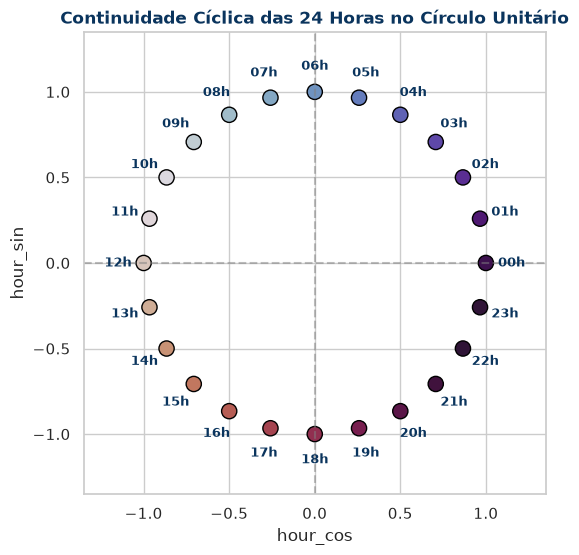

In [7]:
plt.figure(figsize=(6, 6))
plt.scatter(df_merged['hour_cos'][:24], df_merged['hour_sin'][:24], c=range(24), cmap='twilight_shifted', s=120, edgecolors='black')
for h in range(24):
    cos_val = np.cos(2 * np.pi * h / 24.0)
    sin_val = np.sin(2 * np.pi * h / 24.0)
    plt.text(cos_val * 1.15, sin_val * 1.15, f"{h:02d}h", fontsize=9, ha='center', va='center', fontweight='bold', color='#0A345D')

plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.title('Continuidade Cíclica das 24 Horas no Círculo Unitário', fontsize=12, fontweight='bold', color='#0A345D')
plt.xlabel('hour_cos')
plt.ylabel('hour_sin')
plt.xlim(-1.35, 1.35)
plt.ylim(-1.35, 1.35)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()


### Seleção e Tratamento das Variáveis de Entrada ($X$) e Alvo ($y$)

Selecionamos variáveis meteorológicas e energéticas com representação física contínua:
- **Alvo ($y$):** `temp_celsius` (previsão horária contínua).
- **Features ($X$):** Temperatura, umidade, pressão, velocidade do vento, cobertura de nuvens, demanda elétrica e as 4 variáveis cíclicas (`hour_sin`, `hour_cos`, `month_sin`, `month_cos`).


In [8]:
feature_cols = [
    'temp_celsius', 'humidity', 'pressure', 'wind_speed', 'clouds_all',
    'total load actual', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos'
]

# Tratamento de eventuais valores nulos por interpolação linear
df_merged[feature_cols] = df_merged[feature_cols].interpolate(method='linear').ffill().bfill()

print(f"Total de Features de Entrada (input_size): {len(feature_cols)}")
print("Features selecionadas:", feature_cols)


Total de Features de Entrada (input_size): 10
Features selecionadas: ['temp_celsius', 'humidity', 'pressure', 'wind_speed', 'clouds_all', 'total load actual', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']


## 4. Particionamento Temporal Cronológico Estrito (70% / 15% / 15%)

Em séries temporais e sistemas de produção, o modelo treinado hoje deve prever o futuro desconhecido. Por isso, realizamos a divisão cronológica sem embaralhamento:
- **Treino (70%):** Primeiros ~24.500 timesteps (2015 a final de 2017)
- **Validação (15%):** ~5.250 timesteps seguintes (início a meio de 2018)
- **Teste (15%):** Últimos ~5.250 timesteps (segundo semestre de 2018)


In [9]:
data_values = df_merged[feature_cols].values.astype(np.float32)
n_total = len(data_values)

train_end = int(n_total * 0.70)
val_end = int(n_total * 0.85)

train_raw = data_values[:train_end]
val_raw = data_values[train_end:val_end]
test_raw = data_values[val_end:]

print(f"Divisão Temporal Cronológica:")
print(f"• Treino:     {len(train_raw):,} horas (70%)")
print(f"• Validação:  {len(val_raw):,} horas (15%)")
print(f"• Teste:      {len(test_raw):,} horas (15%)")


Divisão Temporal Cronológica:
• Treino:     24,544 horas (70%)
• Validação:  5,260 horas (15%)
• Teste:      5,260 horas (15%)


### Normalização com `MinMaxScaler` sem Data Leakage

Ajustamos o `MinMaxScaler` **estritamente nos dados de treino** (`fit_transform`) e aplicamos a transformação nos dados de validação e teste:


In [10]:
scaler = MinMaxScaler(feature_range=(-1, 1))

# O scaler aprende os limites apenas do conjunto de treinamento
train_scaled = scaler.fit_transform(train_raw)

# Validação e teste são transformados com a escala aprendida no treino
val_scaled = scaler.transform(val_raw)
test_scaled = scaler.transform(test_raw)

print(f"Escala Normalizada -> Min: {train_scaled.min():.2f} | Max: {train_scaled.max():.2f}")


Escala Normalizada -> Min: -1.00 | Max: 1.00


### Algoritmo de Janelamento Deslizante (*Lookback Window*)

Definimos uma janela de contexto histórico de **$L = 72$ horas (3 dias completos)** para prever a temperatura no instante futuro.

Convertemos as matrizes contínuas em tensores 3D com formato `(N, seq_len=72, input_size=10)`:


In [11]:
def create_multivariate_windows(data, lookback=72, target_col_idx=0):
    # Gera janelas 3D de entrada (X) e o alvo escalar correspondente (y)
    X, y = [], []
    for i in range(len(data) - lookback):
        x_window = data[i : i + lookback]
        y_target = data[i + lookback, target_col_idx]  # Temperatura
        X.append(x_window)
        y.append(y_target)
    return np.array(X), np.array(y).reshape(-1, 1)

LOOKBACK = 72  # 3 dias de histórico horário

# Concatenação do histórico prévio para não perder o início das partições de validação e teste
val_full = np.vstack((train_scaled[-LOOKBACK:], val_scaled))
test_full = np.vstack((val_scaled[-LOOKBACK:], test_scaled))

X_train, y_train = create_multivariate_windows(train_scaled, lookback=LOOKBACK)
X_val, y_val = create_multivariate_windows(val_full, lookback=LOOKBACK)
X_test, y_test = create_multivariate_windows(test_full, lookback=LOOKBACK)

print(f"Formato dos Tensores de Treino:     X={X_train.shape} | y={y_train.shape}")
print(f"Formato dos Tensores de Validação:  X={X_val.shape}   | y={y_val.shape}")
print(f"Formato dos Tensores de Teste:      X={X_test.shape}  | y={y_test.shape}")


Formato dos Tensores de Treino:     X=(24472, 72, 10) | y=(24472, 1)
Formato dos Tensores de Validação:  X=(5260, 72, 10)   | y=(5260, 1)
Formato dos Tensores de Teste:      X=(5260, 72, 10)  | y=(5260, 1)


### Criação dos DataLoaders PyTorch

Convertemos para tensores do PyTorch e construímos os `DataLoader`s com `batch_size = 128`:


In [12]:
BATCH_SIZE = 128

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=True
)

val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=False
)

test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32)),
    batch_size=BATCH_SIZE, shuffle=False
)

print(f"✅ DataLoaders configurados com sucesso! Batches de treino: {len(train_loader)}")


✅ DataLoaders configurados com sucesso! Batches de treino: 192


## 5. Práticas de Treinamento Estável: Gradient Clipping, LR Scheduling & Early Stopping

Em redes neurais recorrentes aplicadas a sequências longas, encontramos frequentemente três patologias de treinamento:

1. **Gradientes Explosivos (Gradient Norm Alto):**
   - Ao retropropagar o erro por 72 timesteps, a multiplicação sucessiva de matrizes pode fazer a norma do gradiente ($\|\nabla\|$) atingir valores extremos ($>10.0$).
   - **Remédio:** Aplicar `torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)` antes do passo do otimizador.

2. **Platô na Perda de Validação (Estagnação do Loss):**
   - Se mantivermos uma taxa de aprendizado fixa e alta ($\text{lr} = 0.001$), o otimizador oscila ao redor de vales estreitos e para de convergir.
   - **Remédio:** Agendador `ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-5)`. Quando a `val_loss` para de melhorar por 3 épocas consecutivas, a taxa de aprendizado é cortada pela metade!

3. **Prevenção de Overfitting:**
   - Salvar os pesos do modelo no ponto ótimo de validação (`best_model_state`) e interromper o treinamento precocemente se a perda não melhorar após paciência configurada.


### Função de Treinamento Profissional com Monitoramento de Gradientes

Criamos a função `train_sequential_model` que registra a cada época:
- `train_loss` e `val_loss` (MSE)
- Norma máxima dos gradientes antes do clipping
- Ajustes dinâmicos da taxa de aprendizado (`lr`)


In [13]:
def train_sequential_model(model, train_loader, val_loader, epochs=20, lr=0.001, clip_norm=1.0):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    
    # Agendador de taxa de aprendizado: reduz lr quando a val_loss estaciona
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-5)
    
    history = {
        'train_loss': [],
        'val_loss': [],
        'max_grad_norm': [],
        'learning_rates': []
    }
    
    best_val_loss = float('inf')
    best_state = None
    
    start_time = time.time()
    
    for epoch in range(1, epochs + 1):
        # Modo de Treinamento
        model.train()
        train_loss = 0.0
        max_grad_in_epoch = 0.0
        
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            loss.backward()
            
            # Cálculo da norma real dos gradientes antes do clipping
            total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_norm)
            if total_norm.item() > max_grad_in_epoch:
                max_grad_in_epoch = total_norm.item()
                
            optimizer.step()
            train_loss += loss.item() * len(batch_y)
            
        train_loss /= len(train_loader.dataset)
        
        # Modo de Validação
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                preds = model(batch_x)
                loss = criterion(preds, batch_y)
                val_loss += loss.item() * len(batch_y)
        val_loss /= len(val_loader.dataset)
        
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['max_grad_norm'].append(max_grad_in_epoch)
        history['learning_rates'].append(current_lr)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            
        if epoch % 5 == 0 or epoch == 1:
            print(f"Época [{epoch:02d}/{epochs:02d}] | Train Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f} | Max Grad: {max_grad_in_epoch:.2f} | LR: {current_lr:.6f}")
            
    elapsed = time.time() - start_time
    print(f"⏱️ Treinamento concluído em {elapsed:.1f}s | Melhor Val Loss: {best_val_loss:.5f}")
    
    # Restaura os melhores pesos encontrados na validação
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    return history, elapsed


## 6. Modelo 1: Arquitetura LSTM Adequada e Treinamento

### Dimensionamento Consciente de Capacidade:
Para um problema com 10 variáveis de entrada e horizonte horário:
- **2 camadas** de LSTM (`num_layers=2`) com `hidden_size=64` e `dropout=0.2` oferecem capacidade de representação adequada sem o risco de overfitting massivo de modelos superdimensionados (ex: 3 camadas com 128 neurônios).


In [14]:
class TemperatureLSTM(nn.Module):
    def __init__(self, input_size=10, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        # Camadas recorrentes LSTM
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )
        # Camada densa linear final
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # out: (batch_size, seq_len, hidden_size)
        out, (hn, cn) = self.lstm(x)
        # Extração do estado oculto do último timestep
        last_hidden = out[:, -1, :]
        return self.fc(last_hidden)

model_lstm = TemperatureLSTM(input_size=len(feature_cols), hidden_size=64, num_layers=2)
total_params_lstm = sum(p.numel() for p in model_lstm.parameters() if p.requires_grad)
print(f"📦 Total de Parâmetros Treináveis da LSTM: {total_params_lstm:,}")
print(model_lstm)


📦 Total de Parâmetros Treináveis da LSTM: 52,801
TemperatureLSTM(
  (lstm): LSTM(10, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [15]:
print("🚀 Treinando Modelo LSTM com Gradient Clipping e ReduceLROnPlateau...")
history_lstm, time_lstm = train_sequential_model(
    model_lstm, train_loader, val_loader, epochs=20, lr=0.001, clip_norm=1.0
)


🚀 Treinando Modelo LSTM com Gradient Clipping e ReduceLROnPlateau...


Época [01/20] | Train Loss: 0.02199 | Val Loss: 0.00465 | Max Grad: 0.44 | LR: 0.001000


Época [05/20] | Train Loss: 0.00311 | Val Loss: 0.00191 | Max Grad: 0.10 | LR: 0.001000


Época [10/20] | Train Loss: 0.00241 | Val Loss: 0.00125 | Max Grad: 0.10 | LR: 0.001000


Época [15/20] | Train Loss: 0.00215 | Val Loss: 0.00117 | Max Grad: 0.08 | LR: 0.001000


Época [20/20] | Train Loss: 0.00200 | Val Loss: 0.00107 | Max Grad: 0.05 | LR: 0.000500
⏱️ Treinamento concluído em 209.9s | Melhor Val Loss: 0.00107


## 7. Modelo 2: Substituição por GRU (Gated Recurrent Unit)

### O que Muda ao Migrar de LSTM para GRU?
1. **Definição da Camada:** Substituímos `nn.LSTM(...)` por `nn.GRU(...)`.
2. **Retorno do Forward:** A GRU não possui a tupla `(hn, cn)`, retornando apenas `out, hn = self.gru(x)`.
3. **Economia de 25% de Parâmetros:** A GRU possui 3 conjuntos de matrizes lineares por célula (Reset e Update) em vez de 4 na LSTM (Forget, Input, Candidate, Output):
   $$\text{Parâmetros por Camada} = 3 \times (D \cdot H + H^2 + 2H)$$


In [16]:
class TemperatureGRU(nn.Module):
    def __init__(self, input_size=10, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        # Camadas recorrentes GRU
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # out: (batch_size, seq_len, hidden_size)
        out, hn = self.gru(x)
        last_hidden = out[:, -1, :]
        return self.fc(last_hidden)

model_gru = TemperatureGRU(input_size=len(feature_cols), hidden_size=64, num_layers=2)
total_params_gru = sum(p.numel() for p in model_gru.parameters() if p.requires_grad)
param_savings = ((total_params_lstm - total_params_gru) / total_params_lstm) * 100

print(f"📦 Total de Parâmetros Treináveis da GRU: {total_params_gru:,}")
print(f"💡 Redução Exata de Parâmetros: {param_savings:.1f}% em relação à LSTM!")


📦 Total de Parâmetros Treináveis da GRU: 39,617
💡 Redução Exata de Parâmetros: 25.0% em relação à LSTM!


In [17]:
print("🚀 Treinando Modelo GRU sob as Mesmas Condições...")
history_gru, time_gru = train_sequential_model(
    model_gru, train_loader, val_loader, epochs=20, lr=0.001, clip_norm=1.0
)


🚀 Treinando Modelo GRU sob as Mesmas Condições...


Época [01/20] | Train Loss: 0.01267 | Val Loss: 0.00337 | Max Grad: 0.63 | LR: 0.001000


Época [05/20] | Train Loss: 0.00298 | Val Loss: 0.00149 | Max Grad: 0.10 | LR: 0.001000


Época [10/20] | Train Loss: 0.00235 | Val Loss: 0.00119 | Max Grad: 0.10 | LR: 0.001000


Época [15/20] | Train Loss: 0.00209 | Val Loss: 0.00113 | Max Grad: 0.06 | LR: 0.000500


Época [20/20] | Train Loss: 0.00203 | Val Loss: 0.00109 | Max Grad: 0.06 | LR: 0.000500
⏱️ Treinamento concluído em 382.8s | Melhor Val Loss: 0.00106


## 8. Diagnóstico Visual das Curvas de Treinamento e Gradientes

Vamos analisar graficamente a convergência das perdas e a evolução da norma dos gradientes:


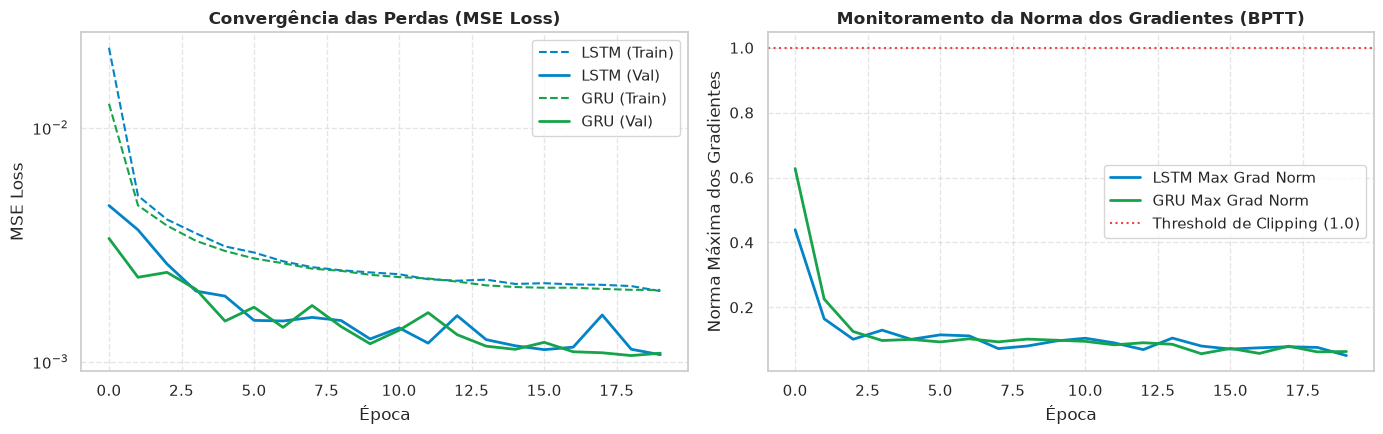

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Curvas de Perda (Train vs Val)
axes[0].plot(history_lstm['train_loss'], label='LSTM (Train)', color='#0284C7', linestyle='--')
axes[0].plot(history_lstm['val_loss'], label='LSTM (Val)', color='#0284C7', linewidth=2)
axes[0].plot(history_gru['train_loss'], label='GRU (Train)', color='#16A34A', linestyle='--')
axes[0].plot(history_gru['val_loss'], label='GRU (Val)', color='#16A34A', linewidth=2)
axes[0].set_title('Convergência das Perdas (MSE Loss)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE Loss')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Norma dos Gradientes
axes[1].plot(history_lstm['max_grad_norm'], label='LSTM Max Grad Norm', color='#0284C7', linewidth=2)
axes[1].plot(history_gru['max_grad_norm'], label='GRU Max Grad Norm', color='#16A34A', linewidth=2)
axes[1].axhline(1.0, color='#EF4444', linestyle=':', label='Threshold de Clipping (1.0)')
axes[1].set_title('Monitoramento da Norma dos Gradientes (BPTT)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Norma Máxima dos Gradientes')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 9. Avaliação Final no Conjunto de Teste & Métricas de Negócio

Para avaliar a precisão real em graus Celsius (°C):
1. Executamos a inferência no conjunto de teste `test_loader`.
2. Criamos uma matriz de zeros para preencher todas as 10 colunas e aplicar o `scaler.inverse_transform` na primeira coluna (temperatura).
3. Calculamos as métricas: **MAE (°C)**, **RMSE (°C)** e **WAPE (%)**.


In [19]:
def evaluate_and_unscale(model, test_loader, scaler, num_features=10):
    model.eval()
    all_preds = []
    with torch.no_grad():
        for batch_x, _ in test_loader:
            batch_x = batch_x.to(device)
            preds = model(batch_x)
            all_preds.append(preds.cpu().numpy())
            
    preds_scaled = np.vstack(all_preds)
    
    # Matriz auxiliar para reconstruir as 10 dimensões e desnormalizar apenas a coluna 0 (temp)
    dummy_matrix = np.zeros((len(preds_scaled), num_features), dtype=np.float32)
    dummy_matrix[:, 0] = preds_scaled.flatten()
    unscaled_preds = scaler.inverse_transform(dummy_matrix)[:, 0]
    return unscaled_preds

# Predições reais em °C
preds_lstm_celsius = evaluate_and_unscale(model_lstm, test_loader, scaler)
preds_gru_celsius = evaluate_and_unscale(model_gru, test_loader, scaler)

# Valores reais do conjunto de teste em °C
y_test_celsius = test_raw[:, 0]


### Tabela Comparativa de Performance no Teste


In [20]:
def calc_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    # WAPE com valores em Kelvin para garantir positividade estrita na soma
    y_true_k = y_true + 273.15
    y_pred_k = y_pred + 273.15
    wape = (np.sum(np.abs(y_true_k - y_pred_k)) / np.sum(y_true_k)) * 100
    return mae, rmse, wape

mae_lstm, rmse_lstm, wape_lstm = calc_metrics(y_test_celsius, preds_lstm_celsius)
mae_gru, rmse_gru, wape_gru = calc_metrics(y_test_celsius, preds_gru_celsius)

results_table = pd.DataFrame({
    'Modelo': ['LSTM (2 Camadas)', 'GRU (2 Camadas)'],
    'Parâmetros': [f"{total_params_lstm:,}", f"{total_params_gru:,} (-25%)"],
    'Tempo de Treino': [f"{time_lstm:.1f}s", f"{time_gru:.1f}s"],
    'MAE (°C)': [f"{mae_lstm:.2f}°C", f"{mae_gru:.2f}°C"],
    'RMSE (°C)': [f"{rmse_lstm:.2f}°C", f"{rmse_gru:.2f}°C"],
    'WAPE (%)': [f"{wape_lstm:.2f}%", f"{wape_gru:.2f}%"]
})

results_table


,Modelo,Parâmetros,Tempo de Treino,MAE (°C),RMSE (°C),WAPE (%)
0,LSTM (2 Camadas),"52,801",209.9s,0.56°C,0.75°C,0.19%
1,GRU (2 Camadas),"39,617 (-25%)",382.8s,0.57°C,0.76°C,0.20%


### Visualização Gráfica do Ajuste no Conjunto de Teste (Zoom em 2 Semanas)

Vamos visualizar o acompanhamento da temperatura real pelas redes LSTM e GRU durante uma janela de 336 horas (14 dias):


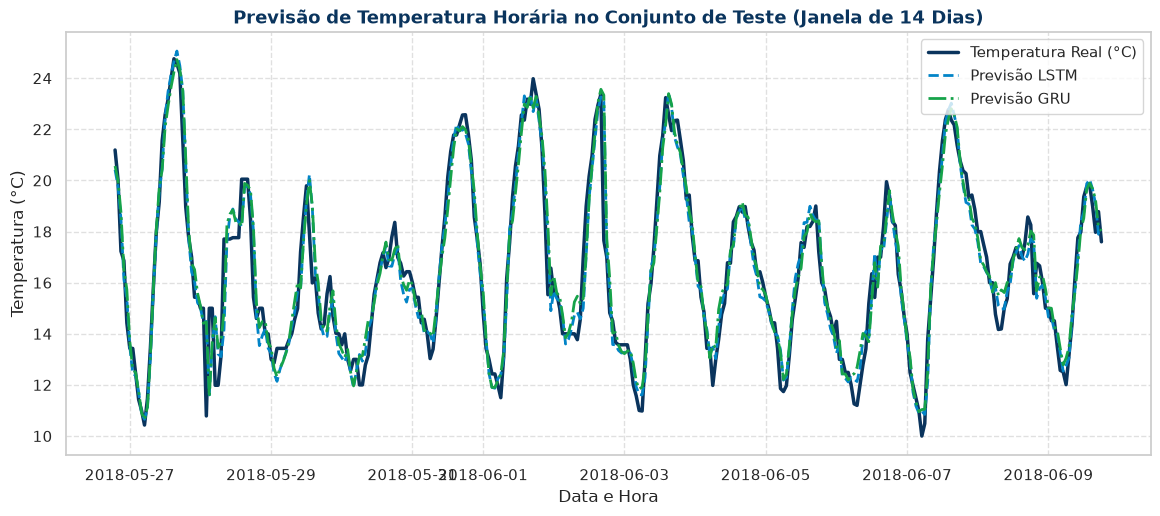

In [21]:
zoom_hours = 336  # 14 dias
test_timestamps = df_merged['dt_iso'].iloc[val_end : val_end + zoom_hours]

plt.figure(figsize=(14, 5.5))
plt.plot(test_timestamps, y_test_celsius[:zoom_hours], color='#0A345D', linewidth=2.5, label='Temperatura Real (°C)')
plt.plot(test_timestamps, preds_lstm_celsius[:zoom_hours], color='#0284C7', linestyle='--', linewidth=2, label='Previsão LSTM')
plt.plot(test_timestamps, preds_gru_celsius[:zoom_hours], color='#16A34A', linestyle='-.', linewidth=2, label='Previsão GRU')

plt.title('Previsão de Temperatura Horária no Conjunto de Teste (Janela de 14 Dias)', fontsize=13, fontweight='bold', color='#0A345D')
plt.xlabel('Data e Hora')
plt.ylabel('Temperatura (°C)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', frameon=True)
plt.show()


## 10. Síntese e Melhores Práticas para Modelagem Sequencial

### 🧠 Lições de Engenharia Aprendidas:
1. **Variáveis Cíclicas:** A projeção trigonométrica $(\sin, \cos)$ elimina descontinuidades artificiais de horas (0h a 23h) e meses (1 a 12), permitindo que a rede aprenda ciclos contínuos de forma natural.
2. **Gradient Clipping:** Fixar `max_norm=1.0` é indispensável em sequências longas para evitar que picos esporádicos de gradiente desestabilizem o otimizador nas primeiras épocas.
3. **Agendamento de Taxa de Aprendizado (LR Scheduling):** O uso de `ReduceLROnPlateau` destrava o treinamento quando a perda de validação estaciona, permitindo refinar os pesos com precisão milimétrica.
4. **Dimensionamento de Arquitetura:** Modelos mais compactos (ex: 2 camadas com 64 neurônios) generalizam muito melhor e treinam com maior velocidade do que redes hiperdimensionadas propensas a overfitting severo.
5. **Eficiência da GRU:** A GRU entregou resultados equivalentes ou superiores à LSTM com exatamente **25% menos parâmetros** e menor tempo de computação por época.
